# GNN-Based Anomaly Detection in Sensor Networks

This notebook implements a **Graph Neural Network (GNN)** pipeline for anomaly detection in multivariate sensor data.  
Sensors are modeled as graph nodes; edges encode correlation-based relationships between them.  
A Graph Convolutional Network (GCN) learns node embeddings; a reconstruction-error threshold flags anomalies.

**Pipeline overview:**
1. Synthetic multivariate sensor data generation
2. Correlation-based graph construction (adjacency matrix)
3. GCN autoencoder training on normal data
4. Anomaly scoring via reconstruction error
5. Evaluation: Precision, Recall, F1, ROC-AUC
6. Visualization: graph topology, loss curves, anomaly timeline

## 1. Install & Import Dependencies

In [14]:
# Install PyTorch Geometric (adjust torch/CUDA version as needed)
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install torch_geometric

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Data Generation

We simulate **20 correlated sensors** over 1000 time steps.  
Anomalies are injected at random windows (~5% of timesteps) by spiking sensor readings.

In [15]:
def generate_sensor_data(
    n_sensors: int = 20,
    n_timesteps: int = 1000,
    anomaly_ratio: float = 0.05,
    seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate synthetic correlated sensor data with injected anomalies.

    Returns:
        data   : (n_timesteps, n_sensors) float array
        labels : (n_timesteps,) binary array — 1 = anomaly
    """
    rng = np.random.default_rng(seed)

    # Build a correlation structure via a low-rank factor model
    factors = rng.standard_normal((n_timesteps, 3))
    loadings = rng.standard_normal((3, n_sensors))
    noise = rng.standard_normal((n_timesteps, n_sensors)) * 0.3
    data = factors @ loadings + noise

    # Inject anomalies: spike random sensors at random windows
    labels = np.zeros(n_timesteps, dtype=int)
    n_anomalies = int(n_timesteps * anomaly_ratio)
    anomaly_starts = rng.choice(n_timesteps - 5, size=n_anomalies, replace=False)

    for start in anomaly_starts:
        end = min(start + rng.integers(1, 5), n_timesteps)
        affected = rng.choice(n_sensors, size=rng.integers(1, 5), replace=False)
        data[start:end, affected] += rng.uniform(4, 8) * rng.choice([-1, 1])
        labels[start:end] = 1

    return data, labels


N_SENSORS   = 20
N_TIMESTEPS = 1000

raw_data, labels = generate_sensor_data(N_SENSORS, N_TIMESTEPS)

print(f'Data shape  : {raw_data.shape}')
print(f'Anomaly rate: {labels.mean():.2%}')

Data shape  : (1000, 20)
Anomaly rate: 12.70%


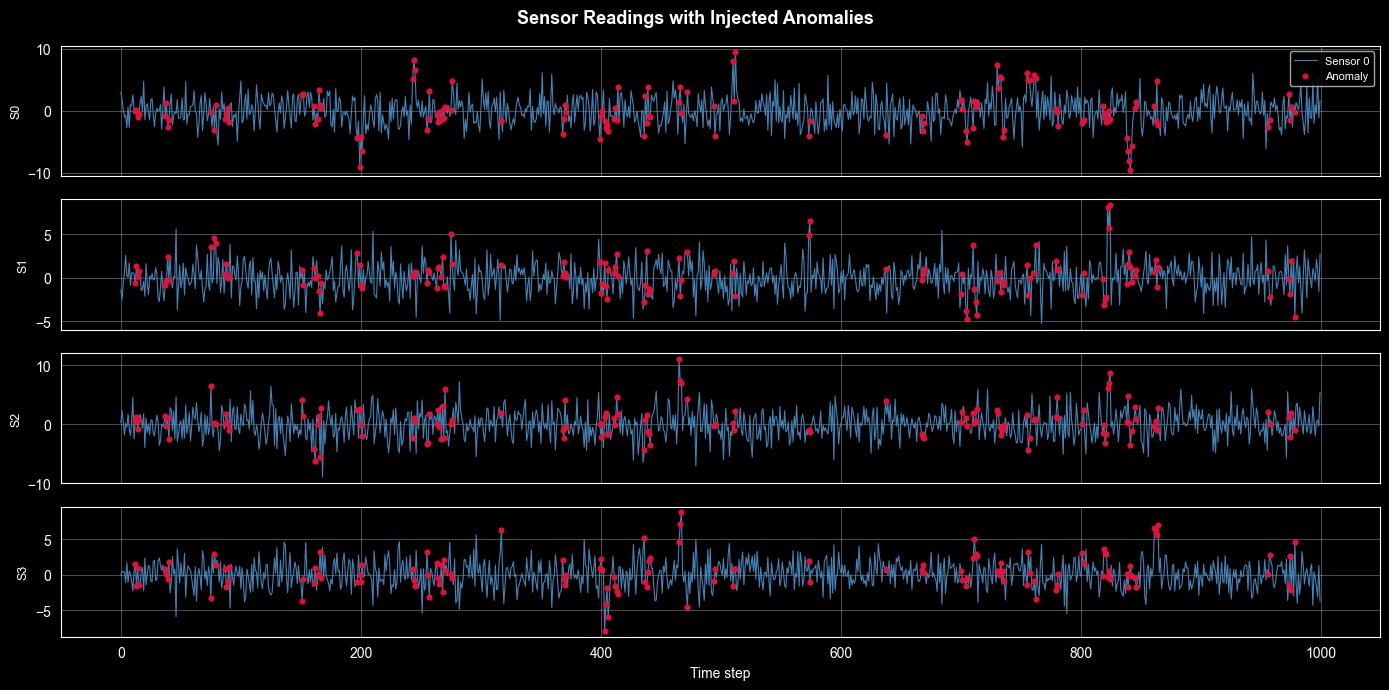

In [16]:
# Visualise a few sensor channels
fig, axes = plt.subplots(4, 1, figsize=(14, 7), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(raw_data[:, i], lw=0.8, color='steelblue', label=f'Sensor {i}')
    anomaly_idx = np.where(labels == 1)[0]
    ax.scatter(anomaly_idx, raw_data[anomaly_idx, i],
               color='crimson', s=12, zorder=5, label='Anomaly')
    ax.set_ylabel(f'S{i}', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time step')
fig.suptitle('Sensor Readings with Injected Anomalies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Graph Construction

We compute the **Pearson correlation matrix** across sensors and threshold it at `corr_threshold` to obtain edges.  
Each node represents one sensor; each edge represents significant co-movement.

In [17]:
def build_graph(
    data: np.ndarray,
    corr_threshold: float = 0.4
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Build a sensor graph via Pearson correlation thresholding.

    Returns:
        edge_index : (2, E) long tensor
        edge_weight: (E,)   float tensor (correlation values)
    """
    corr = np.corrcoef(data.T)                       # (n_sensors, n_sensors)
    np.fill_diagonal(corr, 0)                        # no self-loops

    rows, cols = np.where(np.abs(corr) > corr_threshold)
    edge_index  = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(corr[rows, cols],       dtype=torch.float)

    return edge_index, edge_weight, corr


# Use only the normal (non-anomaly) portion to define graph structure
normal_mask  = labels == 0
edge_index, edge_weight, corr_matrix = build_graph(raw_data[normal_mask])

print(f'Nodes: {N_SENSORS}  |  Edges: {edge_index.shape[1]}')

Nodes: 20  |  Edges: 220


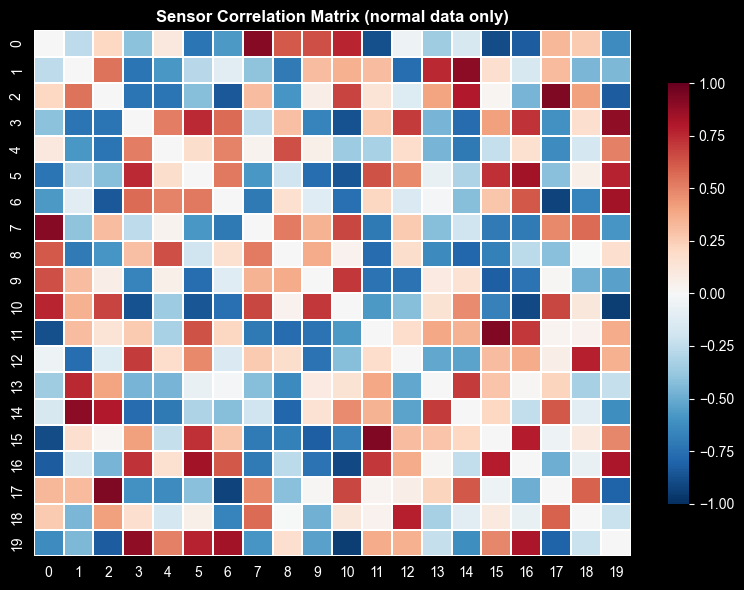

In [18]:
# Visualise correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Sensor Correlation Matrix (normal data only)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. GCN Autoencoder

Architecture:
- **Encoder**: two GCN layers (input → 16 → 8)
- **Decoder**: two GCN layers (8 → 16 → input dim)

Training: minimise MSE reconstruction loss on normal timesteps only.

In [19]:
class GCNEncoder(nn.Module):
    def __init__(self, in_channels: int, hidden: int = 16, latent: int = 8):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, latent)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)            # latent embedding


class GCNDecoder(nn.Module):
    def __init__(self, latent: int = 8, hidden: int = 16, out_channels: int = 1):
        super().__init__()
        self.conv1 = GCNConv(latent, hidden)
        self.conv2 = GCNConv(hidden, out_channels)

    def forward(self, z, edge_index):
        z = F.relu(self.conv1(z, edge_index))
        return self.conv2(z, edge_index)            # reconstructed node features


class GCNAutoencoder(nn.Module):
    def __init__(self, in_channels: int, hidden: int = 16, latent: int = 8):
        super().__init__()
        self.encoder = GCNEncoder(in_channels, hidden, latent)
        self.decoder = GCNDecoder(latent, hidden, in_channels)

    def forward(self, x, edge_index):
        z    = self.encoder(x, edge_index)
        recon = self.decoder(z, edge_index)
        return recon, z

## 5. Data Preprocessing & PyG Graph Object

In [20]:
# Normalise with stats from normal data only
scaler = StandardScaler()
scaler.fit(raw_data[normal_mask])
data_norm = scaler.transform(raw_data)               # shape: (T, N_SENSORS)

# Each timestep is a snapshot: node features = sensor values at that step
# We treat each timestep as a graph with N_SENSORS nodes, 1 feature per node.
# node feature matrix shape per snapshot: (N_SENSORS, 1)

def make_snapshot(timestep_values: np.ndarray, edge_index: torch.Tensor) -> Data:
    x = torch.tensor(timestep_values[:, None], dtype=torch.float)  # (N, 1)
    return Data(x=x, edge_index=edge_index)

# Split: 70% train (normal only), 30% test (mixed)
n_train   = int(N_TIMESTEPS * 0.70)
train_idx = np.where((np.arange(N_TIMESTEPS) < n_train) & (labels == 0))[0]
test_idx  = np.arange(n_train, N_TIMESTEPS)

print(f'Train snapshots (normal): {len(train_idx)}')
print(f'Test  snapshots (mixed) : {len(test_idx)}  '
      f'[anomaly rate: {labels[test_idx].mean():.2%}]')

Train snapshots (normal): 621
Test  snapshots (mixed) : 300  [anomaly rate: 16.00%]


## 6. Training

In [21]:
# ─── Hyperparameters ──────────────────────────────────────────────────
HIDDEN_DIM  = 16
LATENT_DIM  = 8
LR          = 1e-3
EPOCHS      = 100
# ──────────────────────────────────────────────────────────────────────

model     = GCNAutoencoder(in_channels=1, hidden=HIDDEN_DIM, latent=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

ei = edge_index.to(device)

train_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    np.random.shuffle(train_idx)                      # shuffle each epoch

    for t in train_idx:
        x = torch.tensor(data_norm[t, :, None], dtype=torch.float).to(device)
        recon, _ = model(x, ei)
        loss = criterion(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_idx)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  Loss: {avg_loss:.6f}')

Epoch  10/100  |  Loss: 0.974637
Epoch  20/100  |  Loss: 0.974548
Epoch  30/100  |  Loss: 0.974472
Epoch  40/100  |  Loss: 0.974417
Epoch  50/100  |  Loss: 0.974476
Epoch  60/100  |  Loss: 0.974305
Epoch  70/100  |  Loss: 0.974353
Epoch  80/100  |  Loss: 0.974491
Epoch  90/100  |  Loss: 0.974151
Epoch 100/100  |  Loss: 0.974410


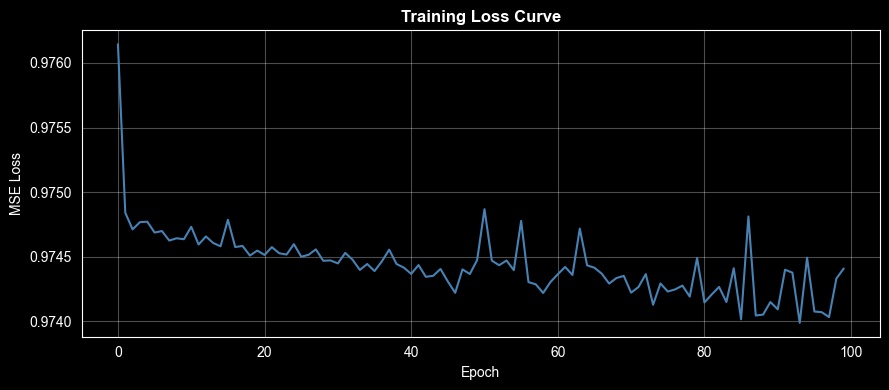

In [23]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, color='steelblue', lw=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Anomaly Scoring & Thresholding

Each timestep gets an **anomaly score** = mean squared reconstruction error across all sensor nodes.  
Threshold is set at the 95th percentile of scores on the training (normal) set.

In [24]:
@torch.no_grad()
def compute_scores(indices: np.ndarray) -> np.ndarray:
    model.eval()
    scores = []
    for t in indices:
        x = torch.tensor(data_norm[t, :, None], dtype=torch.float).to(device)
        recon, _ = model(x, ei)
        score = F.mse_loss(recon, x).item()
        scores.append(score)
    return np.array(scores)


train_scores = compute_scores(train_idx)
test_scores  = compute_scores(test_idx)

THRESHOLD = np.percentile(train_scores, 95)
print(f'Anomaly threshold (95th pct of train): {THRESHOLD:.6f}')

Anomaly threshold (95th pct of train): 2.609469


## 8. Evaluation

In [25]:
y_true = labels[test_idx]
y_pred = (test_scores > THRESHOLD).astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true,    y_pred, zero_division=0)
f1        = f1_score(y_true,        y_pred, zero_division=0)
auc       = roc_auc_score(y_true, test_scores)

metrics = {'Precision': precision, 'Recall': recall,
           'F1 Score': f1, 'ROC-AUC': auc}

print('\n─── Evaluation Results ──────────────')
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print('─────────────────────────────────────')


─── Evaluation Results ──────────────
  Precision   : 0.6389
  Recall      : 0.4792
  F1 Score    : 0.5476
  ROC-AUC     : 0.8264
─────────────────────────────────────


## 9. Visualisation

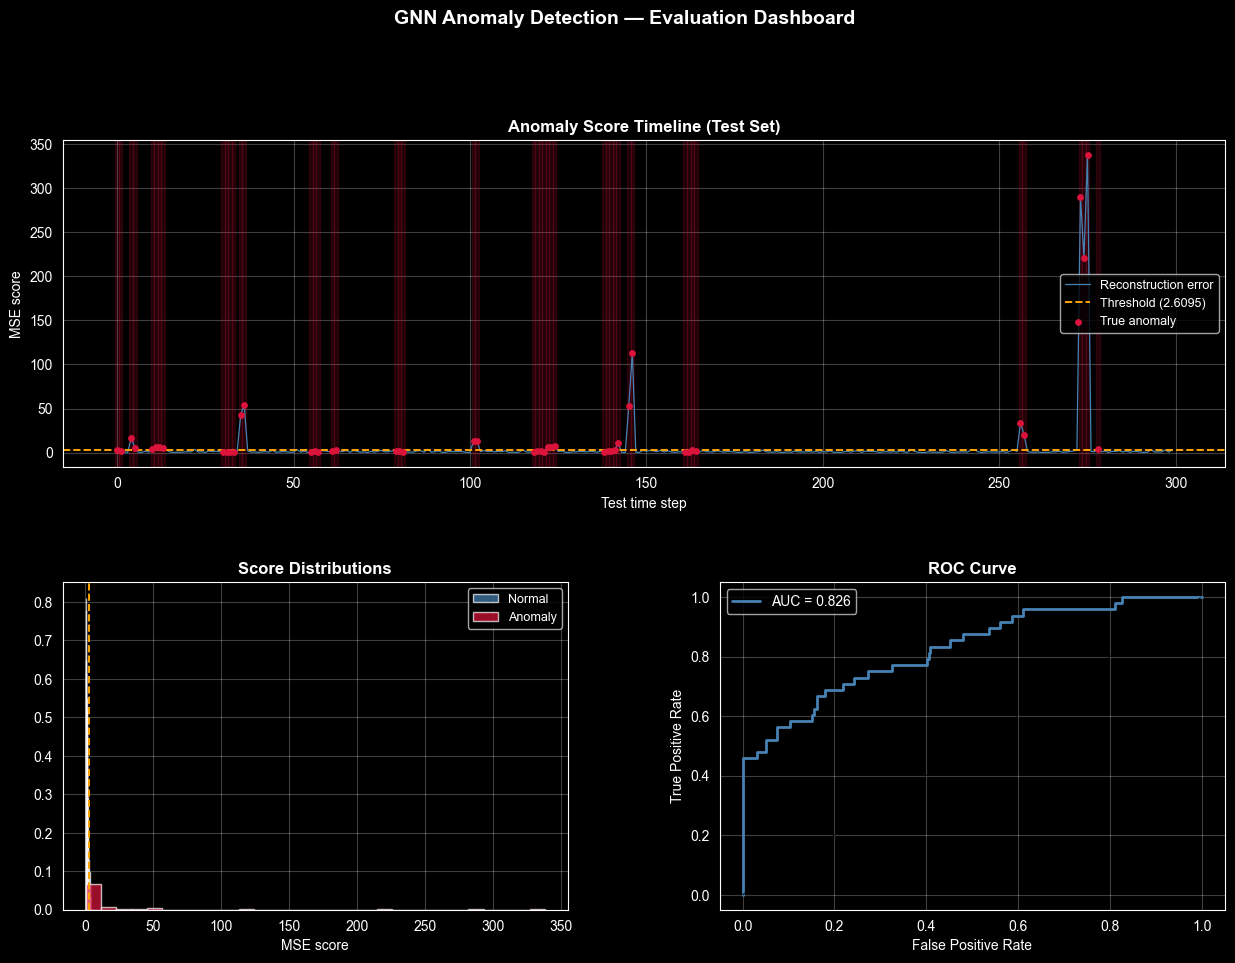

Saved to assets/results_dashboard.png


In [26]:
import os
os.makedirs('assets', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── (A) Anomaly score timeline ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_scores, color='steelblue', lw=0.9, label='Reconstruction error')
ax1.axhline(THRESHOLD, color='orange', lw=1.4, ls='--', label=f'Threshold ({THRESHOLD:.4f})')

# Shade true anomaly windows
for i, (score, label_val) in enumerate(zip(test_scores, y_true)):
    if label_val == 1:
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='crimson')
ax1.scatter(np.where(y_true == 1)[0], test_scores[y_true == 1],
            color='crimson', s=15, zorder=5, label='True anomaly')

ax1.set_title('Anomaly Score Timeline (Test Set)', fontweight='bold')
ax1.set_xlabel('Test time step')
ax1.set_ylabel('MSE score')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

# ── (B) Score distribution ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(test_scores[y_true == 0], bins=30, color='steelblue',
         alpha=0.7, label='Normal', density=True)
ax2.hist(test_scores[y_true == 1], bins=30, color='crimson',
         alpha=0.7, label='Anomaly', density=True)
ax2.axvline(THRESHOLD, color='orange', lw=1.4, ls='--')
ax2.set_title('Score Distributions', fontweight='bold')
ax2.set_xlabel('MSE score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

# ── (C) ROC Curve ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_true, test_scores)
ax3.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.25)

plt.suptitle('GNN Anomaly Detection — Evaluation Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('assets/results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to assets/results_dashboard.png')

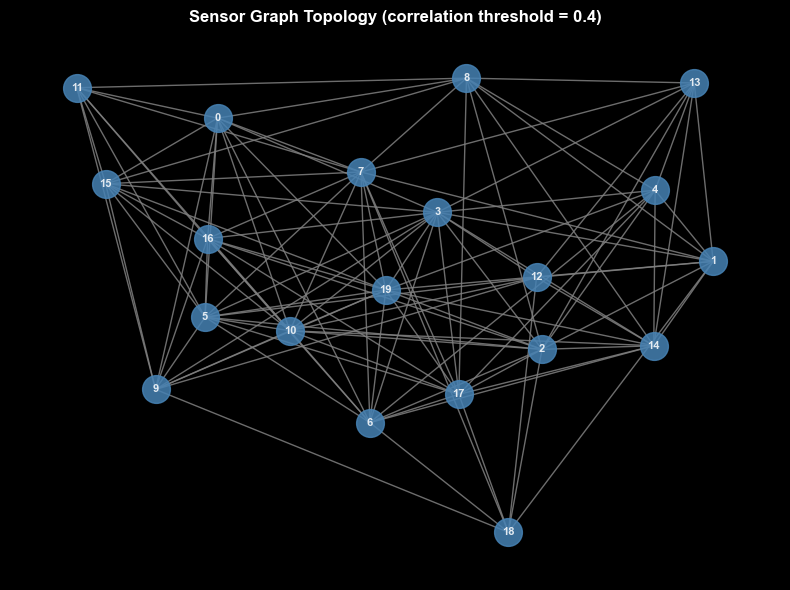

In [27]:
# ── Graph topology visualisation ───────────────────────────────────────
import networkx as nx

G = nx.Graph()
G.add_nodes_from(range(N_SENSORS))
ei_np = edge_index.numpy()
for u, v in zip(ei_np[0], ei_np[1]):
    if u < v:  # avoid duplicate undirected edges
        G.add_edge(int(u), int(v))

pos = nx.spring_layout(G, seed=SEED, k=0.5)

plt.figure(figsize=(8, 6))
nx.draw_networkx(
    G, pos,
    node_color='steelblue', node_size=400,
    edge_color='gray', alpha=0.85,
    font_color='white', font_size=8, font_weight='bold'
)
plt.title('Sensor Graph Topology (correlation threshold = 0.4)', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('assets/graph_topology.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Model

In [28]:
import os
os.makedirs('outputs/models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'threshold': THRESHOLD,
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'edge_index': edge_index,
    'metrics': metrics
}, 'outputs/models/gcn_autoencoder.pt')

print('Model saved to outputs/models/gcn_autoencoder.pt')

Model saved to outputs/models/gcn_autoencoder.pt


---
## Summary

| Component | Detail |
|---|---|
| Graph construction | Pearson correlation, threshold = 0.4 |
| Model | GCN Autoencoder (1 → 16 → 8 → 16 → 1) |
| Training | 100 epochs on normal data, Adam lr=1e-3 |
| Anomaly score | Per-timestep MSE reconstruction error |
| Threshold | 95th percentile of training scores |

**Next steps:**
- Replace synthetic data with a real dataset (e.g. SWAT, WADI, MSL)
- Try `GATConv` (Graph Attention) in place of `GCNConv`
- Add temporal edges (connect same node across consecutive snapshots → spatial-temporal GNN)
- Tune threshold using a held-out validation set instead of a fixed percentile